# Neural network from scratch

In this notebook, I implement a neural network for multi-class classification without using any deep learning frameworks. I also build a neural network with PyTorch for comparison.

Chain rule calculations in a neural network involve several Jacobian matrices. In most cases, the full Jacobians contain lots of zeroes or duplicate numbers, so creating them implicitly instead of explicitly is more efficient. I provide two implementations using both implicit and explicit Jacobians.

In [134]:
from sklearn.datasets import load_iris
import numpy as np
import itertools
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
from torch.utils.data import random_split, DataLoader, TensorDataset
import torch.nn.functional as F

## PyTorch neural network

### Load data

In [135]:
X, y = load_iris(return_X_y=True)
X_torch = torch.from_numpy(X).to(torch.float32)
y_torch = torch.from_numpy(y)
dataset = TensorDataset(X_torch, y_torch)
train_size = int(0.75 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
batch_size = 4
pytorch_train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=False)
pytorch_test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

### Define model

In [136]:
class PyTorchNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(in_features=4, out_features=4)
        self.linear2 = nn.Linear(in_features=4, out_features=3)

    def forward(self, x):
        x = self.linear1(x)
        x = F.relu(x)
        x = self.linear2(x)
        return x

pytorch_model = PyTorchNeuralNetwork()

### Define loss function and optimizer

In [137]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(pytorch_model.parameters(), lr=0.01)

### Train and test model

In [138]:
epochs = 100

pytorch_train_losses = []
pytorch_test_losses = []
pytorch_train_accuracies = []
pytorch_test_accuracies = []

def pytorch_train(model):
    total_loss = 0
    correct = 0
    for x, y in pytorch_train_loader:
        optimizer.zero_grad()
        y_pred_logits = model(x)
        loss = criterion(y_pred_logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        classifications = y_pred_logits.argmax(axis=-1)
        correct += (classifications == y).sum()
    train_loss = total_loss / len(train_dataset)
    train_accuracy = correct / len(train_dataset)
    return train_loss, train_accuracy

def pytorch_test(model):
    total_loss = 0
    correct = 0
    with torch.no_grad():
        for x, y in pytorch_test_loader:
            y_pred_logits = model(x)
            loss = criterion(y_pred_logits, y)
            total_loss += loss.item()
            classifications = y_pred_logits.argmax(axis=-1)
            correct += (classifications == y).sum()
    test_loss = loss / len(test_dataset)
    test_accuracy = correct / len(test_dataset)
    return test_loss, test_accuracy

def pytorch_train_and_test(model, epochs):
    for epoch in range(epochs):
        train_loss, train_accuracy = pytorch_train(model)
        test_loss, test_accuracy = pytorch_test(model)
        pytorch_train_losses.append(train_loss)
        pytorch_train_accuracies.append(train_accuracy)
        pytorch_test_losses.append(test_loss)
        pytorch_test_accuracies.append(test_accuracy)
        if epoch % 20 == 19:
            print(f"Epoch {epoch + 1}/{epochs}")
            print(f"Training loss: {train_loss:.2f}")
            print(f"Training accuracy: {train_accuracy:.0%}")
            print(f"Testing loss: {test_loss:.2f}")
            print(f"Testing accuracy: {test_accuracy:.0%}")
            print()

pytorch_train_and_test(pytorch_model, epochs)

Epoch 20/100
Training loss: 0.09
Training accuracy: 96%
Testing loss: 0.00
Testing accuracy: 92%

Epoch 40/100
Training loss: 0.05
Training accuracy: 97%
Testing loss: 0.00
Testing accuracy: 95%

Epoch 60/100
Training loss: 0.03
Training accuracy: 96%
Testing loss: 0.00
Testing accuracy: 95%

Epoch 80/100
Training loss: 0.03
Training accuracy: 96%
Testing loss: 0.00
Testing accuracy: 95%

Epoch 100/100
Training loss: 0.02
Training accuracy: 96%
Testing loss: 0.00
Testing accuracy: 95%



## Custom neural network

### Load data

In [139]:
rng = np.random.default_rng()

def shuffle_in_unison(*arrays):
    p = rng.permutation(arrays[0].shape[0])
    return [array[p] for array in arrays]

def train_test_split(*arrays, train_size=0.75, shuffle=True):
    if shuffle:
        arrays = shuffle_in_unison(*arrays)
    random_indices = rng.choice(np.arange(arrays[0].shape[0]), size=round(arrays[0].shape[0] * train_size), replace=False)
    mask = np.full(arrays[0].shape[0], False)
    mask[random_indices] = True
    return itertools.chain.from_iterable((array[mask], array[~mask]) for array in arrays)

class DataLoader:
    def __init__(self, X, y, batch_size, shuffle=True):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.length = X.shape[0]
        self.i = 0

    def __iter__(self):
        return self
    
    def __next__(self):
        if self.i < self.length:
            batch = (self.X[self.i : self.i + batch_size], self.y[self.i : self.i + batch_size])
            self.i += batch_size
            return batch
        else:
            self.i = 0 # Reset iterator after exhausting all elements
            if self.shuffle:
                self.X, self.y = shuffle_in_unison(self.X, self.y)
            raise StopIteration

def one_hot_encode(y, num_classes):
    one_hot = np.zeros((y.size, num_classes))
    one_hot[np.arange(y.size), y] = 1
    return one_hot

X, y = load_iris(return_X_y=True)
num_classes = np.unique(y).size
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, shuffle=True)
batch_size = 4
train_loader = DataLoader(X_train, y_train, batch_size, shuffle=False)
test_loader = DataLoader(X_test, y_test, batch_size, shuffle=False)

In [140]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(112, 4)
(112,)
(38, 4)
(38,)


### Loss function

I use a numerically stable version of cross entropy instead of the basic formula.

In [141]:
def log_sum_exp(x):
    # x should be a vector of logits or a batch of vectors of logits.
    c = x.max(axis=-1, keepdims=True)
    return (c + np.log(np.sum(np.exp(x - c), axis=-1, keepdims=True))).flatten()

def cross_entropy_loss(y_pred_logits, y_true):
    # y_pred_logits should contain logits, NOT probabilities
    # y_true should be an integer or a batch of integers
    if isinstance(y_true, np.ndarray): # y_true is a batch
        return -y_pred_logits[np.arange(y_true.shape[0]), y_true] + log_sum_exp(y_pred_logits)
    else: # y_true is an integer
        return -y_pred_logits[y_true] + log_sum_exp(y_pred_logits)

### Linear

In [142]:
class LinearExplicit:
    def __init__(self, input_size, output_size):
        self.input_size = input_size
        self.output_size = output_size

        self.W = rng.random((input_size, output_size))
        self.b = rng.random(output_size)
    
    def forward(self, x):
        self.input = x
        return x @ self.W + self.b

    def backward(self, dloss, learning_rate):
        dW = np.array([
            [
                np.identity(self.output_size) * val
                for val in vector
            ] for vector in self.input
        ]) # Explicit Jacobian. 4D tensor. First dimension is batch size.

        db = np.array([
            np.identity(self.output_size)
            for i in range(self.input.shape[0])
        ]) # Explicit Jacobian. 3D tensor. First dimension is batch size.

        # Multiply each 3D tensor in dW by the corresponding vector in dloss
        dloss_dW = np.einsum("ijkl,il->ijk", dW, dloss)

        # Multiply each matrix in db by the corresponding vector in dloss
        dloss_db = np.matvec(db, dloss)

        # Merge all gradients in batch
        dloss_dW = dloss_dW.sum(axis=0)
        dloss_db = dloss_db.sum(axis=0)

        dloss = np.matvec(self.W, dloss)

        self.W -= learning_rate * dloss_dW
        self.b -= learning_rate * dloss_db

        return dloss

class LinearImplicit:
    def __init__(self, input_size, output_size):
        self.input_size = input_size
        self.output_size = output_size

        self.W = rng.random((input_size, output_size))
        self.b = rng.random(output_size)
    
    def forward(self, x):
        self.input = x
        return x @ self.W + self.b

    def backward(self, dloss, learning_rate):
        dW = self.input # Implicit Jacobian

        # Calculate outer product of each vector in dW
        # with each corresponding vector in dloss
        dloss_dW = np.einsum("ij,ik->ijk", dW, dloss)

        db = 1 # Implicit Jacobian
        dloss_db = db * dloss

        # Merge all gradients in batch
        dloss_dW = dloss_dW.sum(axis=0)
        dloss_db = dloss_db.sum(axis=0)

        dloss = np.matvec(self.W, dloss)

        self.W -= learning_rate * dloss_dW
        self.b -= learning_rate * dloss_db

        return dloss

### ReLU

In [143]:
class ReLUExplicit:
    def forward(self, x):
        self.output = np.maximum(x, 0)
        return self.output

    def backward(self, dloss, learning_rate):
        drelu = np.array([
            np.diag((self.output[i] > 0).astype("float"))
            for i in range(self.output.shape[0])
        ]) # Explicit Jacobian. 3D tensor. First dimension is batch size.
        return np.matvec(drelu, dloss)

class ReLUImplicit:
    def forward(self, x):
        self.output = np.maximum(x, 0)
        return self.output

    def backward(self, dloss, learning_rate):
        drelu = (self.output > 0).astype("float") # Implicit Jacobian
        return drelu * dloss

### Softmax

In [144]:
class SoftmaxExplicit:
    def forward(self, x):
        # Subtract the max value of x for numerical stability
        shifted_x = x - x.max()
        exp_logits = np.exp(shifted_x)
        self.output =  exp_logits / exp_logits.sum(axis=-1, keepdims=True)
        return self.output

    def backward(self, dloss, learning_rate):
        dsoftmax = np.array([
            [
                [
                    self.output[i][j] * (1 - self.output[i][j]) if j == k else -self.output[i][j] * self.output[i][k]
                    for k in range(self.output.shape[1])
                ]
                for j in range(self.output.shape[1])
            ] for i in range(self.output.shape[0])
        ]) # 3D Jacobian. First dimension is batch size.
        return np.matvec(dsoftmax, dloss)

class SoftmaxImplicit:
    def forward(self, x):
        # Subtract the max value of x for numerical stability
        shifted_x = x - x.max()
        exp_logits = np.exp(shifted_x)
        return exp_logits / exp_logits.sum(axis=-1, keepdims=True)

    # A backward function isn't needed here for the implicit implementation.

### Neural network

In [145]:

class NeuralNetworkImplicit:
    def __init__(self, layers):
        self.layers = layers
    
    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        y_pred_logits = x
        softmax = SoftmaxImplicit()
        y_pred_probs = softmax.forward(x)
        return y_pred_logits, y_pred_probs

    def backward(self, y_pred_probs, y_true, learning_rate):
        batch_size = y_pred_probs.shape[0]
        y_true_one_hot = one_hot_encode(y_true, num_classes)

        # Combined derivative of both cross entropy and softmax
        dloss = (y_pred_probs - y_true_one_hot) / batch_size

        for layer in reversed(self.layers):
            dloss = layer.backward(dloss, learning_rate)

class NeuralNetworkExplicit:
    def __init__(self, layers):
        self.layers = layers
    
    def forward(self, x):
        for layer in self.layers[:-1]:
            x = layer.forward(x)
        y_pred_logits = x
        y_pred_probs = self.layers[-1].forward(x)
        return y_pred_logits, y_pred_probs

    def backward(self, y_pred_probs, y_true, learning_rate):
        batch_size = y_pred_probs.shape[0]
        y_true_one_hot = one_hot_encode(y_true, num_classes)
        dloss = (-y_true_one_hot / y_pred_probs) / batch_size
        for layer in reversed(self.layers):
            dloss = layer.backward(dloss, learning_rate)

### Train and test models

In [146]:
explicit_model = NeuralNetworkExplicit([
    LinearExplicit(4, 4),
    ReLUExplicit(),
    LinearExplicit(4, 3),
    SoftmaxExplicit(),
])

implicit_model = NeuralNetworkImplicit([
    LinearImplicit(4, 4),
    ReLUImplicit(),
    LinearImplicit(4, 3),
])

epochs = 100

explicit_train_losses = []
explicit_test_losses = []
explicit_train_accuracies = []
explicit_test_accuracies = []
implicit_train_losses = []
implicit_test_losses = []
implicit_train_accuracies = []
implicit_test_accuracies = []

def train(model, train_losses, train_accuracies):
    loss = 0
    correct = 0
    for X, y in train_loader:
        y_pred_logits, y_pred_probs = model.forward(X)
        loss += cross_entropy_loss(y_pred_logits, y).sum()
        classifications = y_pred_probs.argmax(axis=-1)
        correct += (classifications == y).sum()
        model.backward(y_pred_probs, y, learning_rate=0.01)
    train_loss = loss / len(X_train)
    train_accuracy = correct / len(X_train)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    return train_loss, train_accuracy

def test(model, test_losses, test_accuracies):
    loss = 0
    correct = 0
    for X, y in test_loader:
        y_pred_logits, y_pred_probs = model.forward(X)
        loss += cross_entropy_loss(y_pred_logits, y).sum()
        classifications = y_pred_probs.argmax(axis=-1)
        correct += (classifications == y).sum()
    test_loss = loss / len(X_test)
    test_accuracy = correct / len(X_test)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)
    return test_loss, test_accuracy

def train_and_test(model, epochs, train_losses, test_losses, train_accuracies, test_accuracies):
    for epoch in range(epochs):
        train_loss, train_accuracy = train(model, train_losses, train_accuracies)
        test_loss, test_accuracy = test(model, test_losses, test_accuracies)
        if epoch % 20 == 19:
            print(f"Epoch {epoch + 1}/{epochs}")
            print(f"Training loss: {train_loss:.2f}")
            print(f"Training accuracy: {train_accuracy:.0%}")
            print(f"Testing loss: {test_loss:.2f}")
            print(f"Testing accuracy: {test_accuracy:.0%}")
            print()

In [147]:
train_and_test(
    explicit_model,
    epochs,
    explicit_train_losses,
    explicit_test_losses,
    explicit_train_accuracies,
    explicit_test_accuracies
)

Epoch 20/100
Training loss: 0.34
Training accuracy: 84%
Testing loss: 0.33
Testing accuracy: 89%

Epoch 40/100
Training loss: 0.20
Training accuracy: 93%
Testing loss: 0.20
Testing accuracy: 97%

Epoch 60/100
Training loss: 0.14
Training accuracy: 96%
Testing loss: 0.14
Testing accuracy: 97%

Epoch 80/100
Training loss: 0.12
Training accuracy: 95%
Testing loss: 0.11
Testing accuracy: 95%

Epoch 100/100
Training loss: 0.11
Training accuracy: 95%
Testing loss: 0.09
Testing accuracy: 97%



In [148]:
train_and_test(
    implicit_model,
    epochs,
    implicit_train_losses,
    implicit_test_losses,
    implicit_train_accuracies,
    implicit_test_accuracies
)

Epoch 20/100
Training loss: 0.45
Training accuracy: 76%
Testing loss: 0.44
Testing accuracy: 87%

Epoch 40/100
Training loss: 0.25
Training accuracy: 93%
Testing loss: 0.26
Testing accuracy: 92%

Epoch 60/100
Training loss: 0.16
Training accuracy: 95%
Testing loss: 0.17
Testing accuracy: 97%

Epoch 80/100
Training loss: 0.13
Training accuracy: 94%
Testing loss: 0.13
Testing accuracy: 97%

Epoch 100/100
Training loss: 0.11
Training accuracy: 95%
Testing loss: 0.10
Testing accuracy: 95%



### Results

In [149]:
def plot(train_losses, test_losses, train_accuracies, test_accuracies, name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    fig.suptitle(name)

    ax1.set_title("Loss curve")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.plot(train_losses, label="Training loss")
    ax1.plot(test_losses, label="Testing loss")
    ax1.legend()

    ax2.set_title("Accuracy curve")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Accuracy")
    ax2.plot(train_accuracies, label="Training accuracy")
    ax2.plot(test_accuracies, label="Testing accuracy")
    ax2.legend()

    plt.show()

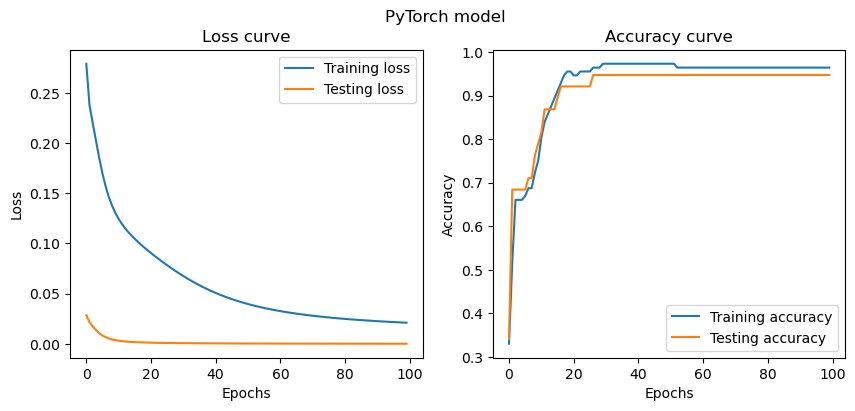

In [150]:
plot(
    pytorch_train_losses,
    pytorch_test_losses,
    pytorch_train_accuracies,
    pytorch_test_accuracies,
    "PyTorch model"
)

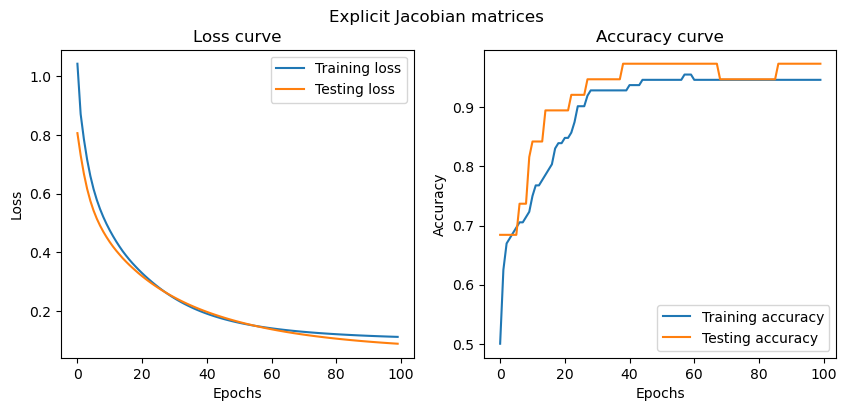

In [151]:
plot(
    explicit_train_losses,
    explicit_test_losses,
    explicit_train_accuracies,
    explicit_test_accuracies,
    "Explicit Jacobian matrices"
)

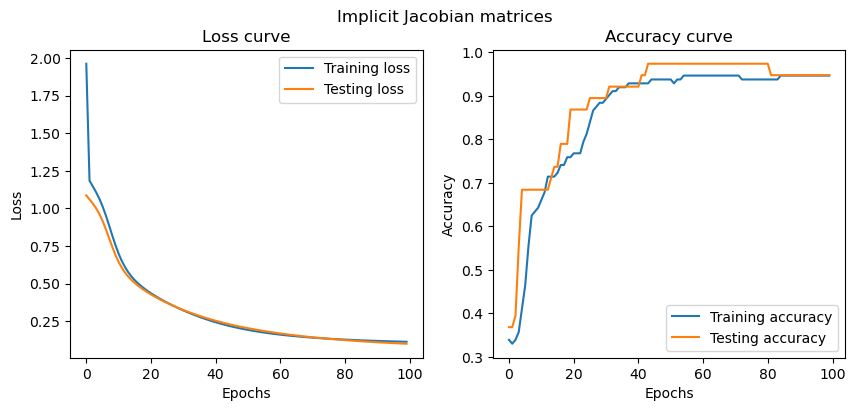

In [152]:
plot(
    implicit_train_losses,
    implicit_test_losses,
    implicit_train_accuracies,
    implicit_test_accuracies,
    "Implicit Jacobian matrices"
)

### Sources:
- https://web.stanford.edu/class/cs224n/readings/gradient-notes.pdf
- https://www.datacamp.com/tutorial/softmax-activation-function-in-python
- https://www.youtube.com/watch?v=RxbL5i8gczg
